<a href="https://colab.research.google.com/github/akashmavle5/--akash/blob/main/Notebook7_CTW_Plus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 7 — Educational Context Tree Weighting (CTW+) and Prediction

This notebook expands the earlier CTW ideas into a richer educational
implementation.

Topics

- Variable-order Markov models
- Context trie
- Krichevsky–Trofimov (KT) estimator
- Recursive context lookup
- Online learning
- Compression-inspired prediction
- Cross-entropy
- Perplexity
- Model comparison

This is an educational approximation, **not** the exact MC-AIXI-CTW algorithm.


In [1]:

import math
import random
import numpy as np
import matplotlib.pyplot as plt

random.seed(0)
np.random.seed(0)


In [2]:

class CTWNode:
    def __init__(self):
        self.count=[0,0]
        self.children={}
    def update(self,s):
        self.count[s]+=1
    def kt(self):
        n=sum(self.count)
        return ((self.count[0]+0.5)/(n+1),
                (self.count[1]+0.5)/(n+1))


In [3]:

class ContextTrie:

    def __init__(self,max_depth=6):
        self.depth=max_depth
        self.root=CTWNode()

    def node(self,ctx):
        n=self.root
        for c in ctx:
            if c not in n.children:
                n.children[c]=CTWNode()
            n=n.children[c]
        return n

    def update(self,history,symbol):
        self.root.update(symbol)
        for d in range(1,self.depth+1):
            ctx=tuple(history[-d:]) if len(history)>=d else tuple(history)
            self.node(ctx).update(symbol)

    def predict(self,history):
        best=self.root
        for d in range(min(len(history),self.depth),0,-1):
            ctx=tuple(history[-d:])
            n=self.node(ctx)
            if sum(n.count)>0:
                best=n
                break
        return best.kt()


In [4]:

def generate_binary_sequence(n=500):
    seq=[]
    for i in range(n):
        if i<5:
            seq.append(random.randint(0,1))
        else:
            seq.append(1 if seq[-1]==seq[-3] else 0)
    return seq

sequence=generate_binary_sequence()
len(sequence)


500

## Online Prediction

In [5]:

tree=ContextTrie(max_depth=6)

history=[]
entropy=[]
logloss=[]
correct=0

for s in sequence:

    p0,p1=tree.predict(history)

    p=max(min(p1 if s else p0,0.999999),1e-6)
    logloss.append(-math.log2(p))

    h=-(p0*math.log2(p0)+p1*math.log2(p1))
    entropy.append(h)

    pred=0 if p0>=p1 else 1
    if pred==s:
        correct+=1

    tree.update(history,s)
    history.append(s)

accuracy=correct/len(sequence)
cross_entropy=np.mean(logloss)
perplexity=2**cross_entropy

print("Accuracy:",round(accuracy,3))
print("Cross Entropy:",round(cross_entropy,3))
print("Perplexity:",round(perplexity,3))


Accuracy: 0.988
Cross Entropy: 0.073
Perplexity: 1.052


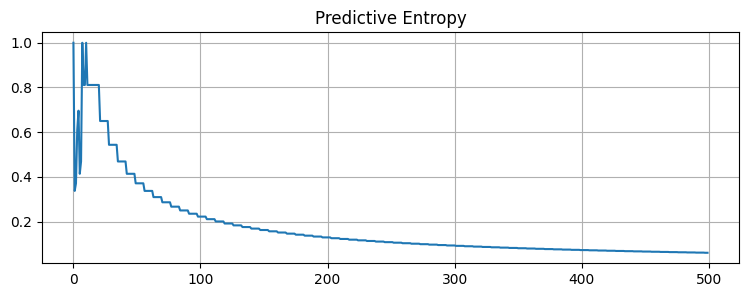

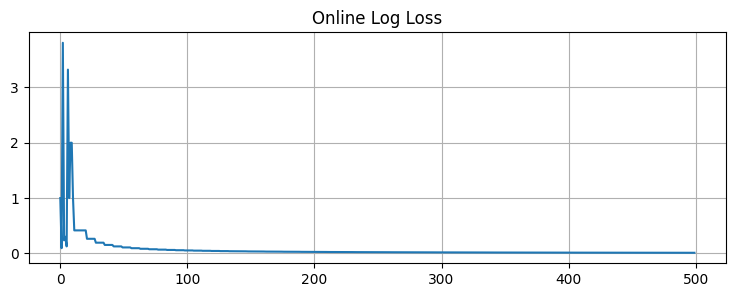

In [6]:

plt.figure(figsize=(9,3))
plt.plot(entropy)
plt.title("Predictive Entropy")
plt.grid()
plt.show()

plt.figure(figsize=(9,3))
plt.plot(logloss)
plt.title("Online Log Loss")
plt.grid()
plt.show()


## Baseline Predictor

In [7]:

class FrequencyPredictor:
    def __init__(self):
        self.c=[1,1]
    def predict(self):
        s=sum(self.c)
        return self.c[0]/s,self.c[1]/s
    def update(self,x):
        self.c[x]+=1

freq=FrequencyPredictor()

ll=[]
correct=0

for s in sequence:
    p0,p1=freq.predict()
    pred=0 if p0>=p1 else 1
    if pred==s:
        correct+=1
    p=max(min(p1 if s else p0,0.999999),1e-6)
    ll.append(-math.log2(p))
    freq.update(s)

print("Baseline accuracy:",round(correct/len(sequence),3))
print("Baseline perplexity:",round(2**np.mean(ll),3))


Baseline accuracy: 0.562
Baseline perplexity: 1.992


## Context Depth Study

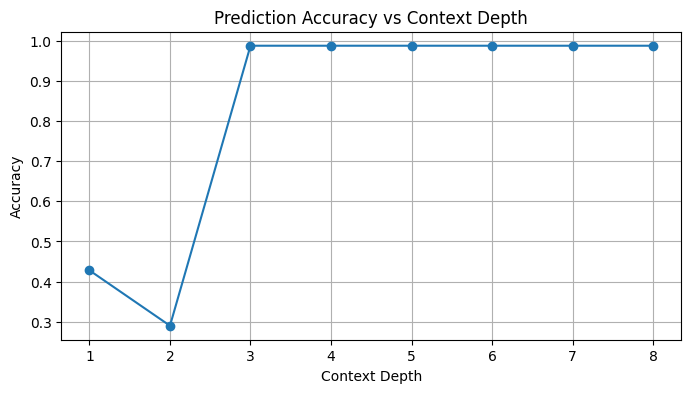

In [8]:

depths=range(1,9)
acc=[]

for d in depths:
    t=ContextTrie(max_depth=d)
    h=[]
    c=0
    for s in sequence:
        p0,p1=t.predict(h)
        if (0 if p0>=p1 else 1)==s:
            c+=1
        t.update(h,s)
        h.append(s)
    acc.append(c/len(sequence))

plt.figure(figsize=(8,4))
plt.plot(list(depths),acc,marker='o')
plt.xlabel("Context Depth")
plt.ylabel("Accuracy")
plt.grid()
plt.title("Prediction Accuracy vs Context Depth")
plt.show()


# Summary

This notebook extends the earlier educational CTW implementation with:

- Recursive context storage
- KT probability estimation
- Online prediction
- Cross-entropy
- Perplexity
- Baseline comparison
- Context-depth experiments

The next notebook will introduce **Monte Carlo Tree Search (UCT/PUCT)**,
bringing the planning component closer to modern model-based agents.
